In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import shap
import matplotlib.pyplot as plt

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
merged_df = pd.read_csv('merged_df.csv')
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone
0,2025-08-13 00:00:00,21.4,29.93,32.71,68.37,70.87,2.06,204.50,0.0,0.0,26.19,11.21,14.96
1,2025-08-13 01:00:00,21.4,29.93,32.71,68.37,70.82,1.47,234.78,0.0,0.0,26.13,11.04,14.61
2,2025-08-13 02:00:00,21.4,29.93,32.71,68.36,70.93,2.18,205.64,0.0,0.0,26.26,11.36,16.14
3,2025-08-13 03:00:00,21.4,29.93,32.71,68.36,71.05,1.73,207.66,0.0,0.2,26.39,15.19,14.63
4,2025-08-13 04:00:00,21.4,29.93,32.71,68.35,70.90,1.85,207.88,0.0,0.0,26.23,17.10,11.88


In [3]:
merged_df['TIMESTAMP'] = pd.to_datetime(merged_df['TIMESTAMP'])

In [4]:
#Feature Engineering
merged_df["hour"] = merged_df["TIMESTAMP"].dt.hour
merged_df["day"] = merged_df["TIMESTAMP"].dt.day
merged_df["month"] = merged_df["TIMESTAMP"].dt.month

In [5]:
merged_df.head()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,AT,NO2,Ozone,hour,day,month
0,2025-08-13 00:00:00,21.4,29.93,32.71,68.37,70.87,2.06,204.50,0.0,0.0,26.19,11.21,14.96,0,13,8
1,2025-08-13 01:00:00,21.4,29.93,32.71,68.37,70.82,1.47,234.78,0.0,0.0,26.13,11.04,14.61,1,13,8
2,2025-08-13 02:00:00,21.4,29.93,32.71,68.36,70.93,2.18,205.64,0.0,0.0,26.26,11.36,16.14,2,13,8
3,2025-08-13 03:00:00,21.4,29.93,32.71,68.36,71.05,1.73,207.66,0.0,0.2,26.39,15.19,14.63,3,13,8
4,2025-08-13 04:00:00,21.4,29.93,32.71,68.35,70.90,1.85,207.88,0.0,0.0,26.23,17.10,11.88,4,13,8


In [6]:
#Lag Features
for lag in [1, 3, 6, 12, 24, 48, 168]:
    merged_df[f"PM25_lag_{lag}"] = merged_df["PM2.5"].shift(lag)
    merged_df[f"PM10_lag_{lag}"] = merged_df["PM10"].shift(lag)

In [7]:
#Rolling Features
merged_df["PM25_roll_mean_6"] = merged_df["PM2.5"].rolling(6).mean()
merged_df["PM10_roll_mean_6"] = merged_df["PM10"].rolling(6).mean()

In [8]:
#Wind Direction Conversion
merged_df["WD_sin"] = np.sin(np.deg2rad(merged_df["WD"]))
merged_df["WD_cos"] = np.cos(np.deg2rad(merged_df["WD"]))

In [9]:
#Target Variable
merged_df["target"] = merged_df["PM2.5"]

In [10]:
merged_df = merged_df.dropna()
merged_df.tail()

,TIMESTAMP,PM2.5,PM10,TEMPERATURE,HUMIDITY,RH,WS,WD,SR,RF,...,PM10_lag_24,PM25_lag_48,PM10_lag_48,PM25_lag_168,PM10_lag_168,PM25_roll_mean_6,PM10_roll_mean_6,WD_sin,WD_cos,target
4797,2026-03-14 09:00:00,32.50,55.50,32.50,54.98,71.53,1.31,123.37,225.97,0.0,...,231.00,85.75,189.25,43.75,78.75,26.708333,48.500000,0.835136,-0.550044,32.50
4798,2026-03-14 10:00:00,32.00,55.75,33.42,52.02,70.89,1.10,221.14,328.17,0.0,...,189.25,72.25,154.00,50.33,98.00,30.833333,53.708333,-0.657901,-0.753104,32.00
4799,2026-03-14 11:00:00,31.25,53.00,34.72,48.65,69.21,1.95,212.03,425.88,0.0,...,111.00,66.75,145.00,58.00,111.50,32.791667,56.166667,-0.530363,-0.847771,31.25
4800,2026-03-14 12:00:00,32.75,56.25,35.85,45.52,66.29,2.09,234.81,440.45,0.0,...,77.00,41.25,80.25,68.50,133.00,32.916667,56.708333,-0.817245,-0.576290,32.75
4801,2026-03-14 13:00:00,30.50,52.25,35.80,44.82,64.08,2.59,217.03,222.60,0.0,...,60.00,51.60,102.00,54.00,102.25,32.500000,55.958333,-0.602233,-0.798320,30.50


In [11]:
merged_df.columns

Index(['TIMESTAMP', 'PM2.5', 'PM10', 'TEMPERATURE', 'HUMIDITY', 'RH', 'WS',
       'WD', 'SR', 'RF', 'AT', 'NO2', 'Ozone', 'hour', 'day', 'month',
       'PM25_lag_1', 'PM10_lag_1', 'PM25_lag_3', 'PM10_lag_3', 'PM25_lag_6',
       'PM10_lag_6', 'PM25_lag_12', 'PM10_lag_12', 'PM25_lag_24',
       'PM10_lag_24', 'PM25_lag_48', 'PM10_lag_48', 'PM25_lag_168',
       'PM10_lag_168', 'PM25_roll_mean_6', 'PM10_roll_mean_6', 'WD_sin',
       'WD_cos', 'target'],
      dtype='object')

In [12]:
merged_df = merged_df.drop(columns=['AQI', 'day_of_week'], errors='ignore')

In [35]:
merged_df.to_csv('sensor_weather_df.csv', index=False)

In [17]:
#Train-Test Split
X = merged_df.drop(["target", "TIMESTAMP"], axis=1)
y = merged_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [18]:
xgb_model = XGBRegressor(n_estimators=200, max_depth=6)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost MAE: 5.637477891833523
XGBoost R2: 0.33126360785774633


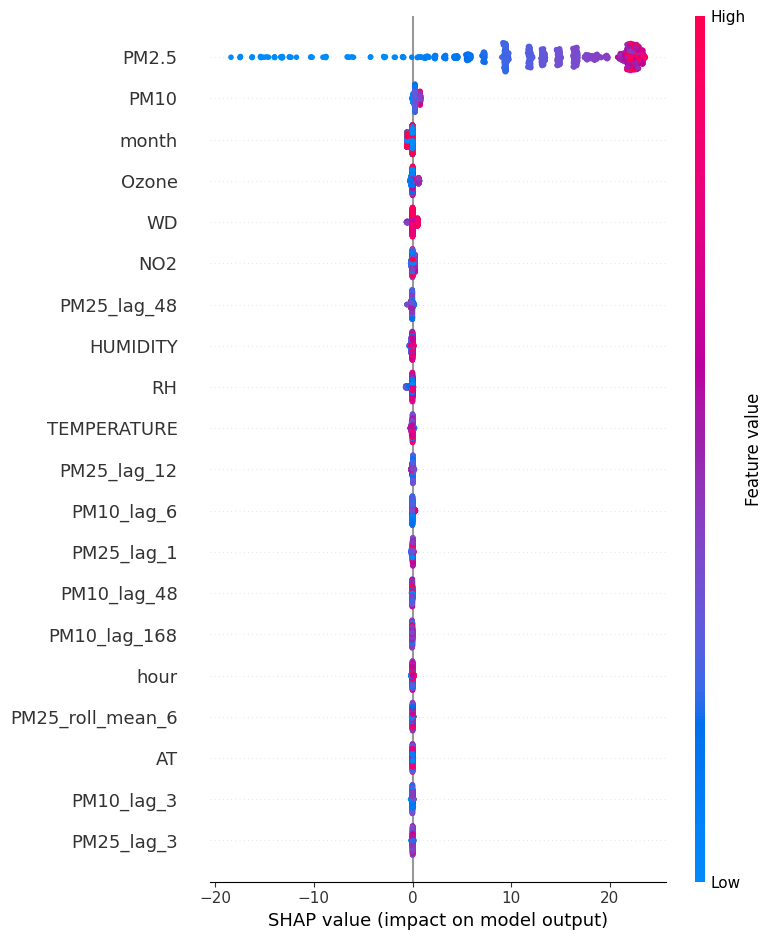

In [19]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [20]:
def create_sequences(X, y, seq_length=24):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X.iloc[i:i+seq_length].values)
        ys.append(y.iloc[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 24

X_lstm, y_lstm = create_sequences(X, y, seq_length)

split = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

In [22]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X.shape[1])),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=32)

Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 237.3545
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 111.7897
Epoch 3/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 62.2405
Epoch 4/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 35.2485
Epoch 5/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 21.7625
Epoch 6/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 15.5387
Epoch 7/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 12.8020
Epoch 8/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 11.7427
Epoch 9/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 11.2695
Epoch 10/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 10.7330
Epoch 11/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 10.1183
Epoch 12/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.5036
Epoch 13/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.8924
Epoch 14/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.3243
Epoch 15/30
116/116 ━━━━━━━━━━

In [23]:
lstm_pred = lstm_model.predict(X_test_lstm)

print("LSTM MAE:", mean_absolute_error(y_test_lstm, lstm_pred))
print("LSTM R2:", r2_score(y_test_lstm, lstm_pred))

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step
LSTM MAE: 11.88452545728704
LSTM R2: -0.08040502021107065


In [24]:
def forecast_lstm(model, last_sequence, steps=168):
    preds = []
    current = last_sequence.copy()

    for _ in range(steps):
        pred = model.predict(current.reshape(1, seq_length, X.shape[1]))[0][0]
        preds.append(pred)

        current = np.roll(current, -1, axis=0)
        current[-1] = pred  # simplified update

    return preds

last_seq = X_lstm[-1]
future_preds = forecast_lstm(lstm_model, last_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━

In [25]:
def construction_decision(pm25):
    if pm25 < 100:
        return "Allowed"
    elif pm25 < 200:
        return "Restricted"
    else:
        return "Not Allowed"

decisions = [construction_decision(p) for p in future_preds]

In [26]:
xgb_score = r2_score(y_test, xgb_pred)
lstm_score = r2_score(y_test_lstm, lstm_pred)

if xgb_score > lstm_score:
    final_model = "XGBoost"
else:
    final_model = "LSTM"

print("Best Model:", final_model)

Best Model: XGBoost


In [27]:
min_len = min(len(xgb_pred), len(lstm_pred))

ensemble_pred = (
    xgb_pred[:min_len] + lstm_pred.flatten()[:min_len]
) / 2

print("Ensemble R2:", r2_score(y_test[:min_len], ensemble_pred))

Ensemble R2: 0.15966796165278108


In [28]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [29]:
lstm_model.save("lstm_model.h5")

In [30]:
joblib.dump(X.columns, "features.pkl")

['features.pkl']

In [31]:
feature_cols = joblib.load("features.pkl")

In [34]:
print("Missing:", set(feature_cols) - set(merged_df.columns))
print("Extra:", set(merged_df.columns) - set(feature_cols))

Missing: set()
Extra: {'TIMESTAMP'}


In [33]:
merged_df = merged_df.drop('target', axis=1)

Create Feature Functions

In [36]:
import numpy as np
import pandas as pd

def create_features(df):
    df = df.copy()
    
    df['hour'] = df['TIMESTAMP'].dt.hour
    df['day'] = df['TIMESTAMP'].dt.day
    df['month'] = df['TIMESTAMP'].dt.month

    # Lag features
    for lag in [1,3,6,12,24,48,168]:
        df[f'PM25_lag_{lag}'] = df['PM2.5'].shift(lag)
        df[f'PM10_lag_{lag}'] = df['PM10'].shift(lag)

    # Rolling
    df['PM25_roll_mean_6'] = df['PM2.5'].rolling(6).mean()
    df['PM10_roll_mean_6'] = df['PM10'].rolling(6).mean()

    # Wind encoding
    df['WD_sin'] = np.sin(np.deg2rad(df['WD']))
    df['WD_cos'] = np.cos(np.deg2rad(df['WD']))

    return df

7 Days Forecast Function

In [37]:
def forecast_next_days(model, df, feature_cols, days=7):
    df = df.copy()
    predictions = []

    for i in range(days):
        # create features
        df_feat = create_features(df)

        # take last row
        last_row = df_feat.iloc[-1:]

        # prepare input
        X = last_row.drop(columns=['TIMESTAMP', 'target', 'impact'], errors='ignore')
        X = X.reindex(columns=feature_cols, fill_value=0)

        # predict
        pred = model.predict(X)[0]

        # create next row
        next_time = df['TIMESTAMP'].iloc[-1] + pd.Timedelta(days=1)

        new_row = df.iloc[-1:].copy()
        new_row['TIMESTAMP'] = next_time
        new_row['PM2.5'] = pred   # 👈 using prediction as next input

        df = pd.concat([df, new_row], ignore_index=True)

        predictions.append({
            "date": next_time,
            "prediction": pred
        })

    return pd.DataFrame(predictions)

In [38]:
def classify_aqi(value):
    if value <= 50:
        return "Good ✅"
    elif value <= 100:
        return "Moderate ⚠️"
    else:
        return "Unhealthy ❌"

Streamlit UI